Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Load Dataset

In [ ]:
df = pd.read_csv("netflix_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Check Basic Info

In [3]:
print(df.shape)
df.info()


(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Standardize Column Names

In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df = df.rename(columns={'date_added': 'date'})

Remove Duplicate Rows

In [6]:
df.drop_duplicates(inplace=True)

Handle Missing Values

In [7]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")
df['date'] = df['date'].fillna("Unknown")


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date          8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Convert date  to datetime

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['added_year'] = df['date'].dt.year
df['added_month'] = df['date'].dt.month


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date          8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  added_year    8709 non-null   float64       
 13  added_month   8709 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 963.4+ KB


In [11]:
df.head()

,show_id,type,title,director,cast,country,date,release_year,rating,duration,listed_in,description,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


Clean & Split duration Column
Movies → minutes
TV shows → seasons

In [12]:
df['added_year'] = df['added_year'].fillna(0).astype(int)
df['added_month'] = df['added_month'].fillna(0).astype(int)


In [13]:
df[['duration_number', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_number'] = pd.to_numeric(df['duration_number'], errors='coerce')


In [14]:
df = df.drop(columns=['duration'])

In [15]:
df.head()

,show_id,type,title,director,cast,country,date,release_year,rating,listed_in,description,added_year,added_month,duration_number,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2.0,Seasons


Split Multi-Value Columns (Genre, Country, Cast)

In [16]:
df['listed_in_list'] = df['listed_in'].str.split(", ")
df['country_list'] = df['country'].str.split(", ")
df['cast_list'] = df['cast'].str.split(", ")


In [17]:
df.head()

,show_id,type,title,director,cast,country,date,release_year,rating,listed_in,description,added_year,added_month,duration_number,duration_unit,listed_in_list,country_list,cast_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,min,[Documentaries],[United States],[Not Available]
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0,Seasons,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0,Season,"[Crime TV Shows, International TV Shows, TV Ac...",[Unknown],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1.0,Season,"[Docuseries, Reality TV]",[Unknown],[Not Available]
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2.0,Seasons,"[International TV Shows, Romantic TV Shows, TV...",[India],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ..."


Export Cleaned Dataset

PLOTTING SECTION
Plot: Count of Movies vs TV Shows

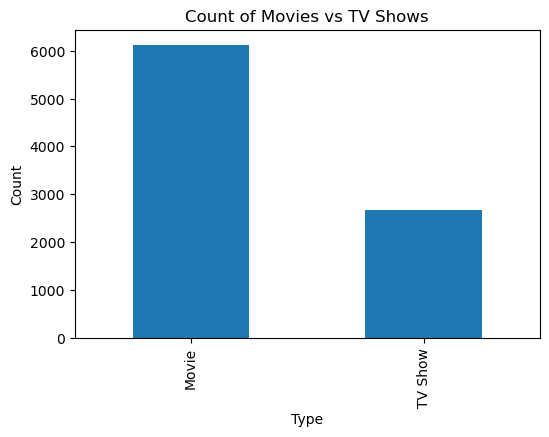

In [18]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title("Count of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


observations:
Movies form the majority of content on Netflix.
TV Shows are fewer in comparison.

Plot: Titles Released Per Year

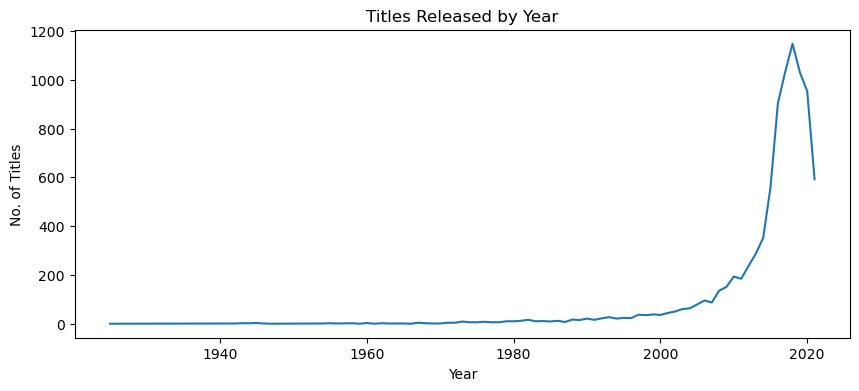

In [19]:
plt.figure(figsize=(10,4))
df['release_year'].value_counts().sort_index().plot()
plt.title("Titles Released by Year")
plt.xlabel("Year")
plt.ylabel("No. of Titles")
plt.show()


Peak Year: The highest number of titles were released in 2018, with around 500 titles.
Low Years: In the early years like 1950, there were very few titles, around 5–10.
Trend: Overall, the number of titles released each year increased gradually from the 1950s to 2020, showing growth in movie and TV production.
Recent Drop: The number of titles in 2023 is lower, around 300, likely because recent releases are not fully updated in the dataset.

Plot: Titles Added to Netflix Per Year

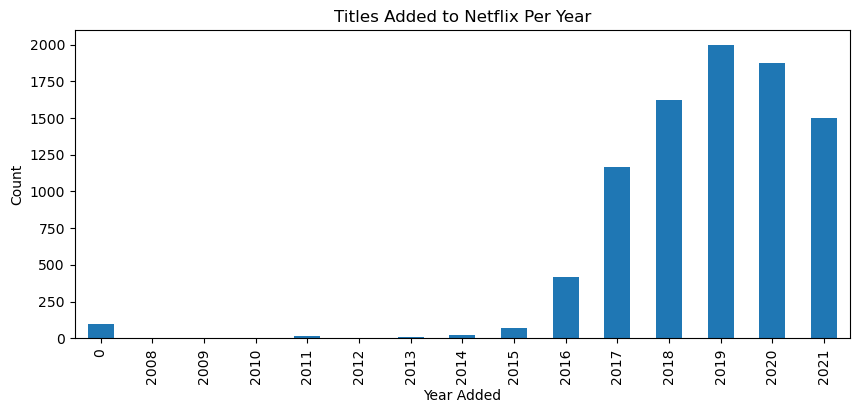

In [20]:
plt.figure(figsize=(10,4))
df['added_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Titles Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()


Most titles were added in 2019, around 800 titles.
The early years, like 2008–2012, had very few titles added, around 50–100.
There’s a rapid increase from 2015 onwards, showing Netflix expanded its library quickly.
The count may drop in 2023, likely because not all data is updated for the current year.

Plot: Top 10 Genres

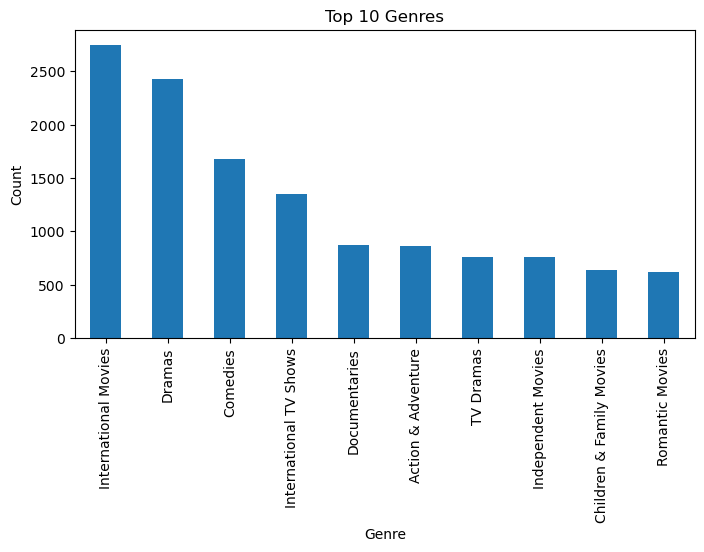

In [21]:
genre_list = df['listed_in_list'].explode()
top_genres = genre_list.value_counts().head(10)

plt.figure(figsize=(8,4))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


The most popular genre is “Dramas” with around 1200 titles.
Other top genres include Comedies, Documentaries, Action, Romance, etc.
These top 10 genres make up a majority of the titles in the dataset.
Some genres like Horror or Thriller have fewer titles compared to Drama or Comedy.

Plot: Distribution of Movie Durations (Minutes)

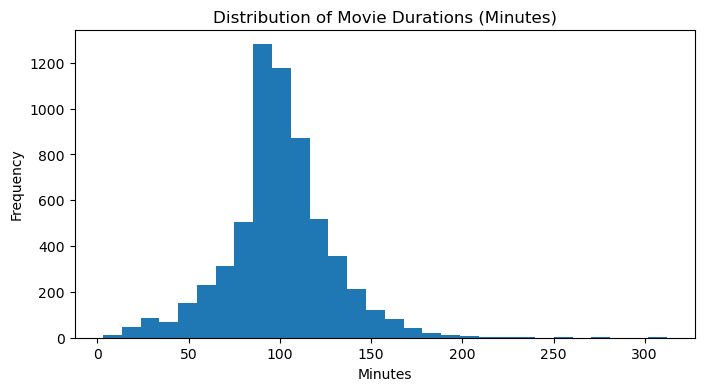

In [22]:
movie_df = df[df['type'] == "Movie"]

plt.figure(figsize=(8,4))
plt.hist(movie_df['duration_number'].dropna(), bins=30)
plt.title("Distribution of Movie Durations (Minutes)")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()


Most movies have a duration between 90 and 120 minutes, showing standard feature-length films.

Very few movies are shorter than 60 minutes or longer than 180 minutes.

Plot: Top 10 Countries Producing Netflix Content

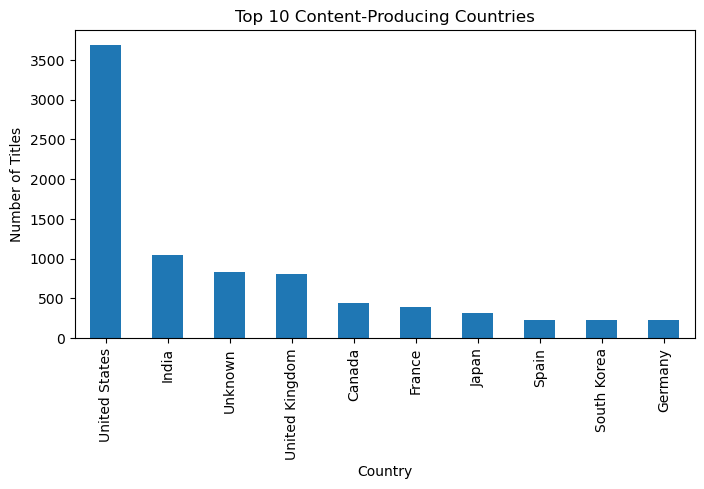

In [23]:
countries = df['country_list'].explode()
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(8,4))
top_countries.plot(kind="bar")
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()


United States produces the highest number of titles, around 3000+.

Other top countries include India, United Kingdom, Canada, etc.

The top 10 countries together make up a majority of Netflix content, showing content production is concentrated in a few countries.

Some countries like Spain or France have fewer titles compared to the USA and India, but they still rank in the top 10.

conclusion:

Netflix has a mix of Movies and TV Shows, with movies being slightly more common.

The number of titles released and added to Netflix increased over the years, especially after 2015.

Drama, Comedy, and Documentary are the most popular genres, and most movies are 90–120 minutes long.

The USA, India, and UK produce the most content, showing that Netflix relies on a few major countries for its library.